In [1]:
import numpy as np
import random
import pandas as pd
from tqdm import tqdm


In [2]:
lengde = 20_000

def create_pop(lengde):
    population = {
        "sex":[random.choice(['K', 'M']) for _ in range(lengde)], 
        "alder":[random.randint(0, 100) for _ in range(lengde)],
        "barn": [0] * lengde
    
    }
    df = pd.DataFrame(population)
  
    return df

create_pop(100_000)

,sex,alder,barn
0,M,86,0
1,M,94,0
2,K,88,0
3,K,17,0
4,M,88,0
...,...,...,...
99995,K,84,0
99996,M,97,0
99997,K,33,0
99998,M,87,0


In [3]:
# Funksjoner
def get_age_group(age):
    if age <= 4:
        return '0-4'
    elif age <= 14:
        return '5-14'
    elif age <= 24:
        return '15-24'
    elif age <= 34:
        return '25-34'
    elif age <= 44:
        return '35-44'
    elif age <= 54:
        return '45-54'
    elif age <= 64:
        return '55-64'
    elif age <= 74:
        return '65-74'
    elif age <= 84:
        return '75-84'
    else:
        return '85+'
    
# Vekter sannsynligheten for å dø i de ulike aldersgruppene
age_groups = {'0-4': 0.00016400164001640017,
  '5-14': 9.840098400984009e-05,
  '15-24': 0.00019680196801968018,
  '25-34': 0.00032800328003280033,
  '35-44': 0.0004920049200492005,
  '45-54': 0.000984009840098401,
  '55-64': 0.0022960229602296024,
  '65-74': 0.006560065600656007,
  '75-84': 0.016400164001640016,
  '85+': 0.052480524805248056}

år = 10_000
fruktbare_år = 20
eldste_fødsel = 35
TFR = 2.2
yearly_pop = []
dødsrate = 0.008 # Ettersom vi kun operer med kvinner her

In [10]:
liste_med_antall_personer = []
df = create_pop()

for year in tqdm(range(år)):
    df.alder += 1
    yearly_pop.append(len(df))

    sannsynlighet_for_barn = TFR / fruktbare_år
    fruktbare_damer = df.loc[(df.alder > eldste_fødsel-fruktbare_år) & (df.alder < eldste_fødsel) & (df.barn < 4) & (df.sex == "K")]

    damer_med_kids = fruktbare_damer.sample(frac=sannsynlighet_for_barn)
    nye_kids = len(damer_med_kids)
    df.loc[damer_med_kids.index, "barn"] += 1

    nye_barn = (
        pd.DataFrame({
            "sex":[random.choice(['K', 'M']) for _ in range(int(nye_kids))], 
            "alder":[0 for _ in range(int(nye_kids))],
            "barn": [0 for _ in range(int(nye_kids))]}))

        # Legg til en kolonne for aldersgruppe
    df['age_group'] = df['alder'].apply(get_age_group)
    
    # Legg til en kolonne for vekter basert på aldersgruppefordelingen
    df['weights'] = df['age_group'].map(age_groups)
    
    # Normaliser vektene slik at de summerer til 1
    df['weights'] = df['weights'] / df['weights'].sum()

    antall_døde = int(len(df)*dødsrate)
    # Sample rader basert på vekter
    sampled_df = df.sample(n=antall_døde, weights='weights', random_state=42).index

    df = df.drop(sampled_df)
    df = pd.concat([df, nye_barn]).reset_index(drop=True)
    df = df.drop("weights", axis=1)
    
    
    liste_med_antall_personer.append(len(df))
    
    

 62% 6150/10000 [07:29<04:41, 13.69it/s]


KeyboardInterrupt: 

In [4]:
age_groups = {"child":0.001,
             "adult" : 0.003,
             "senior": 0.02}

current_average = sum(age_groups.values()) / len(age_groups)
current_average


0.008

In [5]:
3 / fruktbare_år

0.15

In [9]:
innvandring = pd.read_csv("nettoinvandring.csv")
innvandring

,år,nettoinnvandring
0,2007,39652
1,2008,43346
2,2009,38637
3,2010,42346
4,2011,47032
5,2012,47343
6,2013,40073
7,2014,38170
8,2015,29773
9,2016,26093


In [31]:
initial_value = innvandring.nettoinnvandring.mean()

percentage_change = -0.05

# Define the number of iterations
iterations = 102

# Create a list to store the values
values_list = [initial_value]

# Iteratively multiply the value by the percentage change
for i in range(1, iterations):
    new_value = values_list[-1] * (1 + percentage_change)
    values_list.append(new_value)

print(values_list)

[33878.333333333336, 32184.416666666668, 30575.19583333333, 29046.436041666664, 27594.11423958333, 26214.408527604162, 24903.688101223954, 23658.503696162756, 22475.578511354615, 21351.799585786885, 20284.209606497538, 19269.99912617266, 18306.499169864026, 17391.174211370824, 16521.615500802283, 15695.534725762169, 14910.75798947406, 14165.220090000355, 13456.959085500337, 12784.11113122532, 12144.905574664053, 11537.66029593085, 10960.777281134306, 10412.73841707759, 9892.10149622371, 9397.496421412523, 8927.621600341896, 8481.2405203248, 8057.1784943085595, 7654.319569593131, 7271.603591113474, 6908.0234115578, 6562.622240979909, 6234.491128930914, 5922.766572484368, 5626.628243860149, 5345.296831667141, 5078.031990083784, 4824.130390579595, 4582.923871050615, 4353.777677498084, 4136.088793623179, 3929.28435394202, 3732.820136244919, 3546.179129432673, 3368.8701729610393, 3200.426664312987, 3040.4053310973377, 2888.385064542471, 2743.9658113153473, 2606.76752074958, 2476.42914471210

In [6]:
import pandas as pd
import random
from tqdm import tqdm


def get_age_group(age):
    if age < 25:
        return 'child'
    elif age < 65:
        return 'adult'
    else:
        return 'senior'
    
    

def populasjonsutvikling(df, TFR, år, fruktbare_år, eldste_fødsel):
    print(f"Regner populasjon med\nTFR={TFR}\nFruktbare år: {fruktbare_år}\nEldste fødsel: {eldste_fødsel}\n{år} år")
    
    liste_med_antall_personer = []
    sannsynlighet_for_barn = TFR / fruktbare_år

    for year in tqdm(range(år)):
        df['alder'] += 1
        yearly_pop.append(len(df))
        
        fruktbare_damer = df.loc[(df.alder > eldste_fødsel-fruktbare_år) & (df.alder < eldste_fødsel) & (df.barn < 4) & (df.sex == "K")]
        num_fruktbare_damer = len(fruktbare_damer)
        num_nye_kids = int(num_fruktbare_damer * sannsynlighet_for_barn)

        nye_kids = (
            pd.DataFrame({
                "sex": [random.choice(['K', 'M']) for _ in range(num_nye_kids)], 
                "alder": [0] * num_nye_kids,
                "barn": [0] * num_nye_kids}))

        df.loc[fruktbare_damer.sample(num_nye_kids, random_state=42).index, "barn"] += 1

        # Assign weights once
        df['age_group'] = df['alder'].apply(get_age_group)
        df['weights'] = df['age_group'].map(age_groups)

        antall_døde = int(len(df) * dødsrate)
        sampled_df = df.sample(n=antall_døde, weights='weights', random_state=42).index
        df = df.drop(sampled_df)

        df = pd.concat([df, nye_kids]).reset_index(drop=True)
        df.drop(columns=['weights'], inplace=True)

        liste_med_antall_personer.append(len(df))
        
    return liste_med_antall_personer

In [137]:
df = pd.DataFrame()


# Fertilitetsraten i Norge
tfrs = [1.4]

j = 0
for tfr in tfrs:
    print(f"Kjører nummer {tfr}")
    j += 1
    år = 600
    fruktbare_år = 15
    eldste_fødsel = 35
    df_for_run = create_pop(50_000)
    utvikling = populasjonsutvikling(df_for_run, tfr, år, fruktbare_år, eldste_fødsel)
    df[f"TRF = {tfr}"] = pd.Series(utvikling)
    
df

Kjører nummer 2.1


100% 600/600 [00:12<00:00, 46.57it/s]


Kjører nummer 2.2


100% 600/600 [00:15<00:00, 38.58it/s]


Kjører nummer 2.3


...

Kjører nummer 2.4


100% 600/600 [00:25<00:00, 23.27it/s]


Kjører nummer 2.5


100% 600/600 [00:36<00:00, 16.58it/s]


,TRF = 2.1,TRF = 2.2,TRF = 2.3,TRF = 2.4,TRF = 2.5
0,50095,50107,50142,50156,50184
1,50188,50210,50283,50312,50363
2,50279,50313,50422,50459,50540
3,50368,50413,50560,50602,50708
4,50456,50505,50697,50738,50870
...,...,...,...,...,...
595,25317,47585,80472,164307,315401
596,25271,47559,80537,164635,316353
597,25224,47534,80600,164963,317324
598,25178,47512,80662,165295,318296


In [7]:
# Demonstrasjon av Norge

tfr = 1.2
år = 100
fruktbare_år = 15
eldste_fødsel = 35
df_for_run = create_pop(5_547_000)
utvikling = populasjonsutvikling(df_for_run, tfr, år, fruktbare_år, eldste_fødsel)

Regner populasjon med
TFR=1.2
Fruktbare år: 15
Eldste fødsel: 35
100 år


100% 100/100 [03:17<00:00,  1.98s/it]


In [8]:
befolkning_for_2023 = pd.read_csv("befolkning.csv")
befolkning_for_2023

,år,pop
0,1986,4159187
1,1987,4175521
2,1988,4198289
3,1989,4220686
4,1990,4233116
5,1991,4249830
6,1992,4273634
7,1993,4299167
8,1994,4324815
9,1995,4348410


In [10]:
år_start = 2025


befolkningsutvikling = pd.DataFrame()
befolkningsutvikling["år"] = range(år_start, år_start + år)
befolkningsutvikling["pop"] = pd.Series(utvikling)
befolkningsutvikling.to_csv("befolkningsutviling_TFR1_4.csv", index=False)


In [12]:
befolkningfremskrivning

NameError: name 'befolkningfremskrivning' is not defined

In [11]:
befolkningsutvikling

,år,pop
0,2025,5533271
1,2026,5519642
2,2027,5506044
3,2028,5492514
4,2029,5479023
...,...,...
95,2120,3552118
96,2121,3528574
97,2122,3505161
98,2123,3481874


In [29]:
befolkningfremskrivning = pd.concat([befolkning_for_2023, befolkningsutvikling])
befolkningfremskrivning

,år,pop
0,1986,4159187
1,1987,4175521
2,1988,4198289
3,1989,4220686
4,1990,4233116
...,...,...
95,2120,3552118
96,2121,3528574
97,2122,3505161
98,2123,3481874


In [30]:
befolkningfremskrivning.merge(innvandring, on="år", how="left")

,år,pop,nettoinnvandring
0,1986,4159187,NaN
1,1987,4175521,NaN
2,1988,4198289,NaN
3,1989,4220686,NaN
4,1990,4233116,NaN
...,...,...,...
134,2120,3552118,NaN
135,2121,3528574,NaN
136,2122,3505161,NaN
137,2123,3481874,NaN


In [32]:
fremskriving_innvandring = pd.DataFrame({"år":[år for år in range(2023, 2125)], "innvandring_pred":values_list})
fremskriving_innvandring

,år,innvandring_pred
0,2023,33878.333333
1,2024,32184.416667
2,2025,30575.195833
3,2026,29046.436042
4,2027,27594.114240
...,...,...
97,2120,233.943913
98,2121,222.246717
99,2122,211.134382
100,2123,200.577662


In [33]:
befolkningfremskrivning = befolkningfremskrivning.merge(fremskriving_innvandring, on="år", how="left").fillna(0)
befolkningfremskrivning

,år,pop,innvandring_pred
0,1986,4159187,0.000000
1,1987,4175521,0.000000
2,1988,4198289,0.000000
3,1989,4220686,0.000000
4,1990,4233116,0.000000
...,...,...,...
134,2120,3552118,233.943913
135,2121,3528574,222.246717
136,2122,3505161,211.134382
137,2123,3481874,200.577662


In [34]:
befolkningfremskrivning["pop_inn"] = befolkningfremskrivning["pop"]+ befolkningfremskrivning["innvandring_pred"]

In [ ]:
befolkn

<Axes: xlabel='år'>

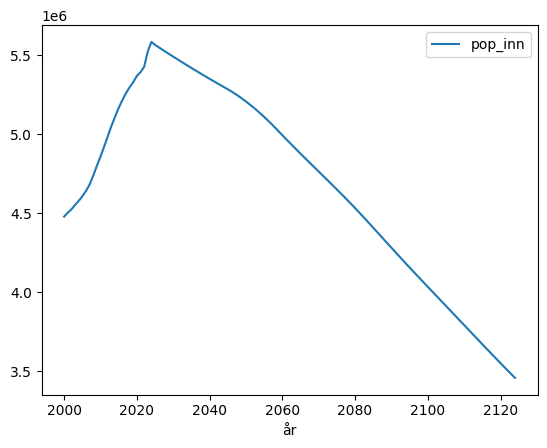

In [37]:
befolkningfremskrivning.loc[lambda x: x.år >= 2000].plot(x="år", y="pop_inn")

In [163]:
befolkningsutvikling.loc[lambda x: x.År == 2100]["pop"].values

array([3987622])